In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('diwali_sales_data.csv')
data.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
data = data.drop(columns=['Status','unnamed1'])

In [ ]:
data.head()

In [4]:
empty_amt = data[data['Amount'].isnull()]
empty_amt.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
14,1003858,Cano,P00293742,M,46-50,46,1,Madhya Pradesh,Central,Hospitality,Auto,3,NaN
16,1005447,Amy,P00275642,F,46-50,48,1,Andhra Pradesh,Southern,IT Sector,Auto,3,NaN
109,1005265,Sakshi,P00296242,F,46-50,48,1,Delhi,Central,Banking,Footwear & Shoes,1,NaN
111,1005261,Apoorva,P00057942,F,36-45,41,1,Delhi,Central,IT Sector,Footwear & Shoes,2,NaN


In [5]:
data = data[data['Amount'].notnull()]

In [6]:
# Total Revenue
total_revenue = data['Amount'].sum()
# Total number of orders
total_orders = data['Orders'].sum()
print(f"Total Revenue: {total_revenue}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: {total_revenue / total_orders}")

Total Revenue: 106249132.43
Total Orders: 27981
Average Order Value: 3797.18853614953


Gender
F    74335856.43
M    31913276.00
Name: Amount, dtype: float64


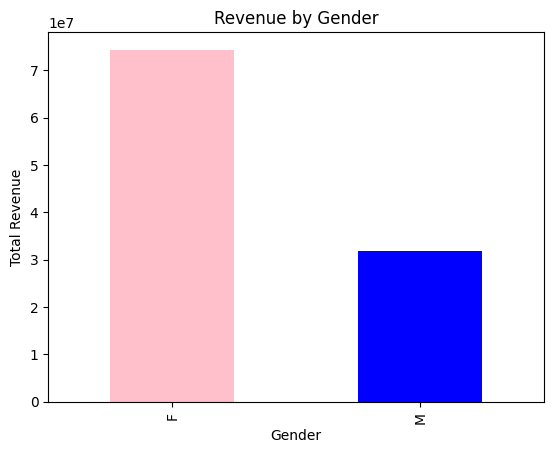

In [7]:
rev_gender = data.groupby('Gender')['Amount'].sum()
print(rev_gender)

rev_gender.plot(kind='bar', color=['pink', 'blue'])
plt.title('Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()

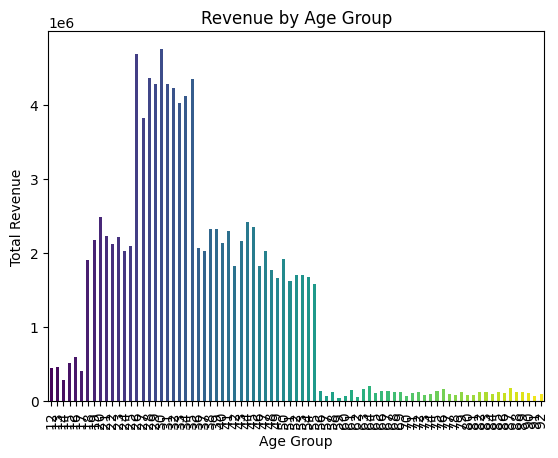

In [ ]:
bins = [0,17,25,32,40,60,100]
labels = ['0-17','18-25','26-32','33-40','41-60','61+']
rev_age = data.groupby(pd.cut(data['Age'], bins=bins, labels=labels))['Amount'].sum()
rev_age.plot(kind='bar', color=sns.color_palette('viridis', len(rev_age)))
plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.show()